In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

from scipy.stats import hypergeom



In [2]:
adata_path = large_data_dir + 'GBM_BC002_genotyped.h5ad'

adata = sc.read_h5ad(adata_path)
gf_utils.assign_genotypes(adata, min_counts=0, min_p=0.6)

adata.obs['cell_type'] = pd.read_csv('../output/GBM_cell_type_labels.txt', sep='\t', index_col=0).loc[adata.obs_names, 'cell_type']
adata.obs['tumor_normal_infercnv'] = pd.read_csv('../output/tumor_normal_labels_infercnv.txt', sep='\t', index_col=0).loc[adata.obs_names, 'infercnv']

variants = ['EGFR VIII', 'CARD11 c.2149G>A', 'AXL c.1103G>A', 'EGFR c.685A>T', 'EGFR c.1889_1894delinsTAGGAT']
adata.obsm['genotype_call'] = adata.obsm['genotype_call'][variants].copy()


In [3]:
bulk_VAFs = {'CARD11 c.2149G>A':0.26, 'AXL c.1103G>A':0.12, 'EGFR c.685A>T':0.11, 'EGFR c.1889_1894delinsTAGGAT':0.09, 'EGFR VIII':None}

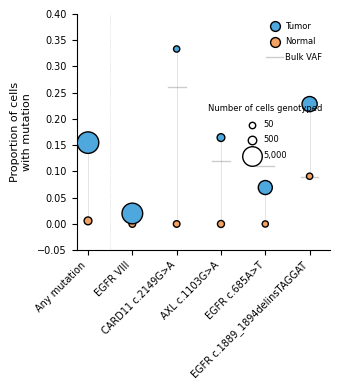

In [4]:
x = np.arange(len(variants))

tumor_vals   = []
normal_vals  = []
tumor_counts = []
normal_counts = []

# "Any mutation" aggregate
any_mut_tumor_total = ((adata.obsm['genotype_call'].loc[adata.obs['tumor_normal_infercnv'] == 'tumor'][variants].isin(['heterozygous','mutated','wt'])).sum(axis=1) > 0).sum()
any_mut_tumor_mut = ((adata.obsm['genotype_call'].loc[adata.obs['tumor_normal_infercnv'] == 'tumor'][variants].isin(['heterozygous','mutated'])).sum(axis=1) > 0).sum()
any_mut_tumor_VAF = (any_mut_tumor_mut / any_mut_tumor_total)

any_mut_normal_total = ((adata.obsm['genotype_call'].loc[adata.obs['tumor_normal_infercnv'] == 'normal'][variants].isin(['heterozygous','mutated','wt'])).sum(axis=1) > 0).sum()
any_mut_normal_mut = ((adata.obsm['genotype_call'].loc[adata.obs['tumor_normal_infercnv'] == 'normal'][variants].isin(['heterozygous','mutated'])).sum(axis=1) > 0).sum()
any_mut_normal_VAF = (any_mut_normal_mut / any_mut_normal_total)

tumor_vals.append(any_mut_tumor_VAF)
normal_vals.append(any_mut_normal_VAF)
tumor_counts.append(any_mut_tumor_total)
normal_counts.append(any_mut_normal_total)

for variant in variants:
    tumor_wt_counts = adata.obsm['genotype_call'].loc[adata.obs['tumor_normal_infercnv'] == 'tumor'][variant].value_counts().get('wt', 0)
    tumor_total_counts = adata.obsm['genotype_call'].loc[adata.obs['tumor_normal_infercnv'] == 'tumor'][variant].notna().sum()
    tumor_VAF = 1 - (tumor_wt_counts / tumor_total_counts)

    normal_wt_counts = adata.obsm['genotype_call'].loc[adata.obs['tumor_normal_infercnv'] == 'normal'][variant].value_counts().get('wt', 0)
    normal_total_counts = adata.obsm['genotype_call'].loc[adata.obs['tumor_normal_infercnv'] == 'normal'][variant].notna().sum()
    normal_VAF = 1 - (normal_wt_counts / normal_total_counts)

    tumor_vals.append(tumor_VAF)
    normal_vals.append(normal_VAF)
    tumor_counts.append(tumor_total_counts)
    normal_counts.append(normal_total_counts)

xlabels = ['Any mutation'] + list(variants)
x = np.arange(len(xlabels))

# Size scaling (for size legend only)
all_counts = np.array(tumor_counts + normal_counts)
size_min, size_max = 10, 120
scaling = 2

def count_to_size(c):
    return size_min + (size_max - size_min) * (c - all_counts.min()) / (all_counts.max() - all_counts.min())

fig, ax = plt.subplots(figsize=(3.5, 4))

# Bulk VAF lines
bulk_vals = []
bulk_x = []
for i, v in enumerate(variants):
    bv = bulk_VAFs.get(v, None)
    if bv is not None:
        bulk_vals.append(bv)
        bulk_x.append(i + 1)
for bx, bv in zip(bulk_x, bulk_vals):
    ax.plot([bx - 0.2, bx + 0.2], [bv, bv],
            color='grey', lw=1, alpha=0.4, zorder=1)

# Connecting lines
for i in range(len(xlabels)):
    ax.plot([x[i], x[i]], [tumor_vals[i], normal_vals[i]],
            color='grey', lw=0.5, alpha=0.3, zorder=0)

# Normal below, tumor on top — scaled dot sizes
sizes_tumor  = count_to_size(np.array(tumor_counts)) * scaling
sizes_normal = count_to_size(np.array(normal_counts)) * scaling

ax.scatter(x, normal_vals, color="#F4A261", edgecolor='k', linewidth=1,
           s=sizes_normal, alpha=1, zorder=2)
ax.scatter(x, tumor_vals,  color="#4EA8DE", edgecolor='k', linewidth=1,
           s=sizes_tumor, alpha=1, zorder=3)

# Main legend — fixed-size dummy entries
ax.scatter([], [], s=50, color="#4EA8DE", edgecolor='k', linewidth=1, alpha=1, label='Tumor')
ax.scatter([], [], s=50, color="#F4A261", edgecolor='k', linewidth=1, alpha=1, label='Normal')
ax.plot([], [], color='grey', lw=1, alpha=0.4, label='Bulk VAF')
leg1 = ax.legend(fontsize=6, frameon=False, loc='upper right',
                 handletextpad=0.3, labelspacing=0.8)
ax.add_artist(leg1)

# Size legend
legend_counts = [50, 500, 5000]
size_handles = [ax.scatter([], [], s=count_to_size(c) * scaling, color='white',
                           edgecolor='k', linewidth=1, alpha=1)
                for c in legend_counts]
ax.legend(size_handles, [f'{c:,}' for c in legend_counts],
          fontsize=6, frameon=False, loc='center right',
          title='Number of cells genotyped', title_fontsize=6,
          handletextpad=0.3, labelspacing=0.8)

ax.set_ylim(-0.05, 0.4)

ax.axvline(0.5, color='grey', ls=':', lw=0.5, alpha=0.4)

ax.set_ylabel('Proportion of cells\nwith mutation', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
ax.tick_params(axis='y', labelsize=7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig('../plots/mutated_proportions.pdf', dpi=300)


In [5]:
### check percent of cells genotyped for each variant
for variant in variants:
    print(variant, adata.obsm['genotype_call'][variant].notna().sum(), adata.obsm['genotype_call'][variant].notna().sum() / adata.shape[0])


EGFR VIII 5744 0.5132237312365976
CARD11 c.2149G>A 104 0.009292351679771264
AXL c.1103G>A 486 0.04342387419585418
EGFR c.685A>T 2318 0.2071122230164403
EGFR c.1889_1894delinsTAGGAT 2803 0.2504467476769121
